## MR Signal as a fucntion of T1, TR, and flip-angle
either signal at steady state, or time efficiency of the three parameters

S = [ (sin alpha) * M_zero *((1 - e ^ -TR / T1))/(1 - (cos alpha) e ^ -TR / T1) * (e ^ -TE / T2_star) ] / sqrt(TR)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from pathlib import Path

import nibabel as nib

from scipy.optimize import curve_fit

In [2]:
def signal_from_T1_alpha_TR(t1_domain, alpha_deg, rep_time, echo_time, t2_star, M_zero = 1.0, B1_factor = 1.0):
    
    alpha = (alpha_deg / 360.0) * (np.pi * 2.0)
    #signal = (np.sin(alpha) * (1 - np.exp(-1 * rep_time / t1_domain)))/(1 - (np.cos(alpha) * np.exp(-1 * rep_time / t1_domain)))
    #signal = (M_zero * ((1 - np.exp(-1 * rep_time / t1_domain))/ \
    #                    (1 - (np.cos(alpha) * np.exp(-1 * rep_time / t1_domain)))) * \
    #                    (np.sin(alpha) * np.exp(-1 * echo_time / t2_star)))
    
    #signal = (M_zero * ((np.sin(alpha)*(1 - np.exp(-1 * rep_time / t1_domain)))/ \
    #                    (1 - (np.cos(alpha) * np.exp(-1 * rep_time / t1_domain)))) * \
    #                    (np.sin(alpha) * np.exp(-1 * echo_time / t2_star)))
    
    signal = (np.sin((alpha * B1_factor)) * M_zero * ((1 - np.exp(-1 * rep_time / t1_domain))/ \
                        (1 - (np.cos((alpha * B1_factor)) * np.exp(-1 * rep_time / t1_domain)))) * \
                        (1 * np.exp(-1 * echo_time / t2_star)))
    
    return signal

def signal_from_T1_alpha_TR_over_sqrtTR(t1_domain, alpha_deg, rep_time, echo_time, t2_star, M_zero = 1.0, B1_factor = 1.0):
    
    alpha = (alpha_deg / 360.0) * (np.pi * 2.0)
    #signal = (np.sin(alpha) * (1 - np.exp(-1 * rep_time / t1_domain)))/(1 - (np.cos(alpha) * np.exp(-1 * rep_time / t1_domain)))
    #signal = (M_zero * ((1 - np.exp(-1 * rep_time / t1_domain))/ \
    #                    (1 - (np.cos(alpha) * np.exp(-1 * rep_time / t1_domain)))) * \
    #                    (np.sin(alpha) * np.exp(-1 * echo_time / t2_star)))
    
    #signal = (M_zero * ((np.sin(alpha)*(1 - np.exp(-1 * rep_time / t1_domain)))/ \
    #                    (1 - (np.cos(alpha) * np.exp(-1 * rep_time / t1_domain)))) * \
    #                    (np.sin(alpha) * np.exp(-1 * echo_time / t2_star)))
    
    signal = ((np.sin((alpha * B1_factor)) * M_zero * ((1 - np.exp(-1 * rep_time / t1_domain))/ \
                        (1 - (np.cos((alpha * B1_factor)) * np.exp(-1 * rep_time / t1_domain)))) * \
                        (1 * np.exp(-1 * echo_time / t2_star))) / np.sqrt(rep_time))
    
    return signal

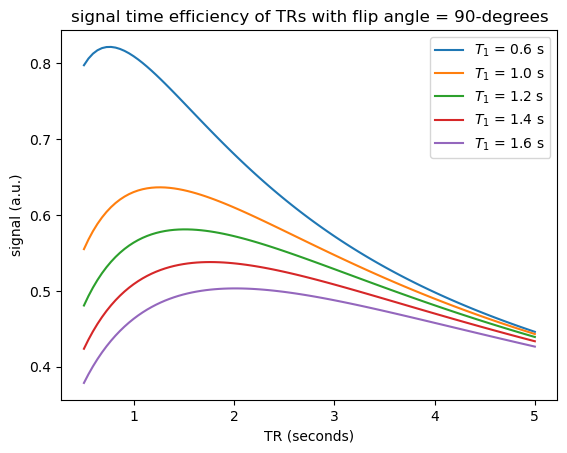

In [3]:
%matplotlib inline
#%matplotlib qt

tr_domain = np.linspace(0.5, 5.0, 101)

sig_0 = signal_from_T1_alpha_TR_over_sqrtTR(1.2, 90.0, tr_domain, 0.025, 10.100)
sig_1 = signal_from_T1_alpha_TR_over_sqrtTR(1.4, 90.0, tr_domain, 0.025, 10.100)
sig_2 = signal_from_T1_alpha_TR_over_sqrtTR(0.6, 90.0, tr_domain, 0.025, 10.100)
sig_3 = signal_from_T1_alpha_TR_over_sqrtTR(1.0, 90.0, tr_domain, 0.025, 10.100)
sig_4 = signal_from_T1_alpha_TR_over_sqrtTR(1.6, 90.0, tr_domain, 0.025, 10.100)
#sig_2 = signal_from_T1_alpha_TR(t1_dom, 7.0, 0.01, 0.003, 0.100)
#sig_3 = signal_from_T1_alpha_TR(t1_dom, 8.0, 0.01, 0.003, 0.100)
#sig_4 = signal_from_T1_alpha_TR(t1_dom, 9.0, 0.01, 0.003, 0.100)
#sig_5 = signal_from_T1_alpha_TR(t1_dom, 10.0, 0.01, 0.003, 0.100)


plt.figure()
plt.plot(tr_domain, sig_2, label='$T_1$ = 0.6 s')
plt.plot(tr_domain, sig_3, label='$T_1$ = 1.0 s')
plt.plot(tr_domain, sig_0, label='$T_1$ = 1.2 s')
plt.plot(tr_domain, sig_1, label='$T_1$ = 1.4 s')
plt.plot(tr_domain, sig_4, label='$T_1$ = 1.6 s')

#plt.plot(t1_dom, sig_1, label='6.0')
#plt.plot(t1_dom, sig_2, label='7.0')
#plt.plot(t1_dom, sig_3, label='8.0')
#plt.plot(t1_dom, sig_4, label='9.0')
#plt.plot(t1_dom, sig_5, label='10.0')
plt.title("signal time efficiency of TRs with flip angle = 90-degrees")
plt.xlabel('TR (seconds)')
plt.ylabel('signal (a.u.)')
plt.legend()
plt.show()

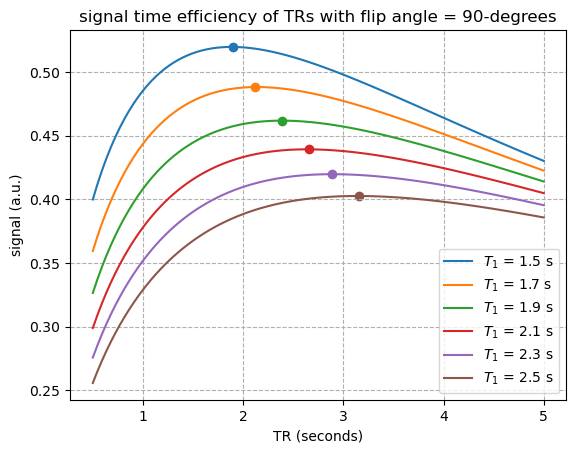

In [4]:
%matplotlib inline
#%matplotlib qt

tr_domain = np.linspace(0.5, 5.0, 101)

sig_0 = signal_from_T1_alpha_TR_over_sqrtTR(1.5, 90.0, tr_domain, 0.025, 10.100)
sig_1 = signal_from_T1_alpha_TR_over_sqrtTR(1.7, 90.0, tr_domain, 0.025, 10.100)
sig_2 = signal_from_T1_alpha_TR_over_sqrtTR(1.9, 90.0, tr_domain, 0.025, 10.100)
sig_3 = signal_from_T1_alpha_TR_over_sqrtTR(2.1, 90.0, tr_domain, 0.025, 10.100)
sig_4 = signal_from_T1_alpha_TR_over_sqrtTR(2.3, 90.0, tr_domain, 0.025, 10.100)
sig_5 = signal_from_T1_alpha_TR_over_sqrtTR(2.5, 90.0, tr_domain, 0.025, 10.100)



plt.figure()
plt.plot(tr_domain, sig_0, label='$T_1$ = 1.5 s')
plt.scatter(tr_domain[sig_0.argmax(axis=0)], sig_0.max())
plt.plot(tr_domain, sig_1, label='$T_1$ = 1.7 s')
plt.scatter(tr_domain[sig_1.argmax(axis=0)], sig_1.max())
plt.plot(tr_domain, sig_2, label='$T_1$ = 1.9 s')
plt.scatter(tr_domain[sig_2.argmax(axis=0)], sig_2.max())
plt.plot(tr_domain, sig_3, label='$T_1$ = 2.1 s')
plt.scatter(tr_domain[sig_3.argmax(axis=0)], sig_3.max())
plt.plot(tr_domain, sig_4, label='$T_1$ = 2.3 s')
plt.scatter(tr_domain[sig_4.argmax(axis=0)], sig_4.max())
plt.plot(tr_domain, sig_5, label='$T_1$ = 2.5 s')
plt.scatter(tr_domain[sig_5.argmax(axis=0)], sig_5.max())


#plt.plot(t1_dom, sig_1, label='6.0')
#plt.plot(t1_dom, sig_2, label='7.0')
#plt.plot(t1_dom, sig_3, label='8.0')
#plt.plot(t1_dom, sig_4, label='9.0')
#plt.plot(t1_dom, sig_5, label='10.0')
plt.title("signal time efficiency of TRs with flip angle = 90-degrees")
plt.xlabel('TR (seconds)')
plt.ylabel('signal (a.u.)')
plt.grid(ls="--")
plt.legend()
plt.show()